<a href="https://colab.research.google.com/github/codebreaker0511/Emotisense/blob/main/Linear_Regression_using_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import matplotlib.pyplot as plt
from torch import nn

In [ ]:
torch.__version__

In [58]:
#Let's create our own dataset

w = 0.6
b = 0.2
start = 0
end = 1
step = 0.02
noise_factor = 0.1

X = torch.arange(start,end,step).unsqueeze(dim=1)
y = w*X + b + noise_factor*torch.rand(X.shape)

In [59]:
#Let's try to print and see the data
X[:10] , y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.2383],
         [0.3079],
         [0.2630],
         [0.2961],
         [0.2737],
         [0.3394],
         [0.3661],
         [0.2973],
         [0.3895],
         [0.3674]]))

In [66]:
indices = torch.randperm(X.shape[0])
X = X[indices]
y= y[indices]

X_train = X[:int(0.8*X.shape[0])]
y_train = y[:int(0.8*y.shape[0])]
X_test = X[int(0.8*X.shape[0]):]
y_test = y[int(0.8*y.shape[0]):]

X_test

tensor([[0.5000],
        [0.7000],
        [0.7400],
        [0.6600],
        [0.9800],
        [0.4000],
        [0.5600],
        [0.6800],
        [0.0200],
        [0.8600]])

In [61]:
def plot_for_visualization(X_Train = X_train,
                           y_Train = y_train,
                           X_Test = X_test,
                           y_Test = y_test,
                           pred = None):
  plt.figure(figsize=(10,7))
  plt.scatter(X_Train,y_Train,c="b",s=15,label="Training Data")
  plt.scatter(X_Test,y_Test,c="r",s=15,label="Test Data")
  if pred is not None:
    plt.plot(X_test,pred,c="g",label="Predictions")
  plt.legend(prop={"size":14})
  plt.show()

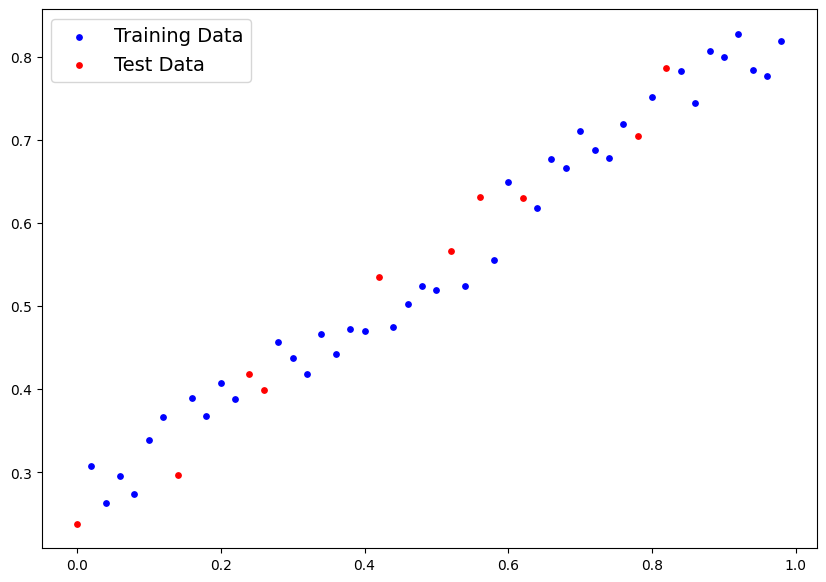

In [62]:
plot_for_visualization()

In [63]:
torch.manual_seed(42)

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.rand(1,
                                           dtype = torch.float,
                                           requires_grad = True))
    self.bias = nn.Parameter(torch.rand(1,
                                           dtype = torch.float,
                                           requires_grad = True))

  def forward(self,X:torch.Tensor) -> torch.Tensor:
      return self.weights*X + self.bias

model_0 = LinearRegressionModel()
model_0.state_dict()


OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

Epoch: 0 | Train_Loss: 0.6570948362350464 | Test_loss: 0.5801575779914856
Epoch: 1000 | Train_Loss: 0.0007630306645296514 | Test_loss: 0.0009452685480937362
Epoch: 2000 | Train_Loss: 0.0007547980640083551 | Test_loss: 0.0008796046604402363
Epoch: 3000 | Train_Loss: 0.0007542561506852508 | Test_loss: 0.0008641547756269574
Epoch: 4000 | Train_Loss: 0.0007542205275967717 | Test_loss: 0.0008602986927144229
Epoch: 5000 | Train_Loss: 0.0007542181410826743 | Test_loss: 0.0008593322709202766
Epoch: 6000 | Train_Loss: 0.000754218315705657 | Test_loss: 0.0008591178921051323
Epoch: 7000 | Train_Loss: 0.000754218315705657 | Test_loss: 0.0008591178921051323
Epoch: 8000 | Train_Loss: 0.000754218315705657 | Test_loss: 0.0008591178921051323
Epoch: 9000 | Train_Loss: 0.000754218315705657 | Test_loss: 0.0008591178921051323


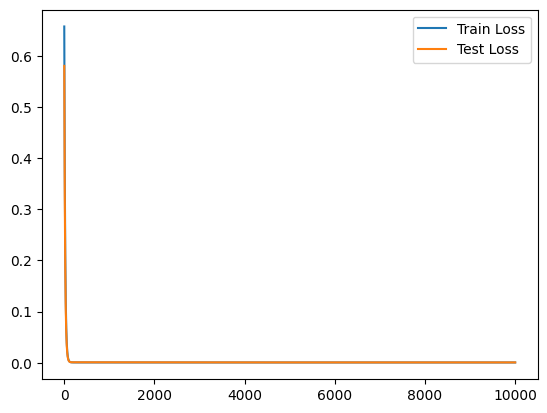

In [64]:
epoches = 10000
epoch_count = []
train_loss = []
test_loss = []

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.01)

for epoch in range(epoches):
  model_0.train()
  y_pred = model_0(X_train)
  loss = loss_fn(y_pred,y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  train_loss.append(loss.item())
  epoch_count.append(epoch)
  model_0.eval()
  with torch.inference_mode():
    test_pred = model_0(X_test)
    test_loss.append(loss_fn(test_pred,y_test).item())
  if epoch % 1000 == 0:
    print(f"Epoch: {epoch} | Train_Loss: {loss.item()} | Test_loss: {loss_fn(test_pred,y_test).item()}")

plt.plot(epoch_count,train_loss,label="Train Loss")
plt.plot(epoch_count,test_loss,label="Test Loss")
plt.legend()
plt.show()


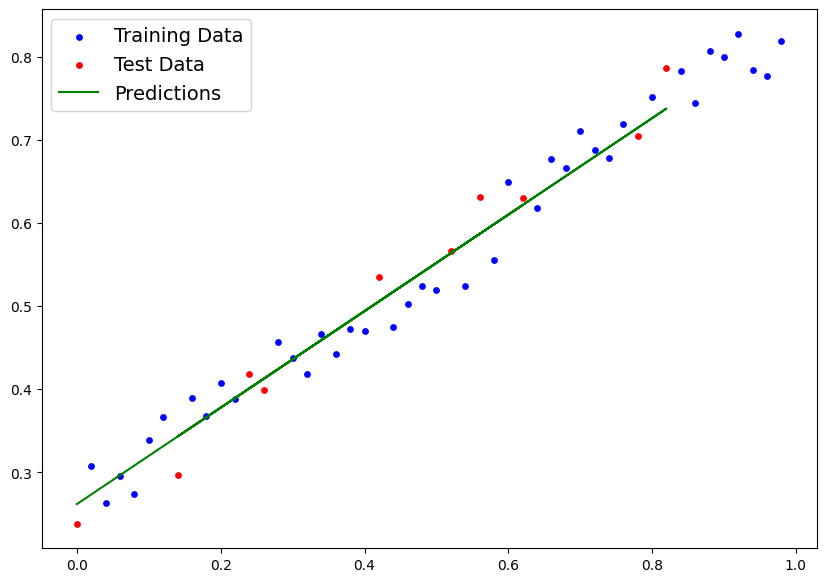

In [65]:
model_0.eval()
with torch.no_grad():
  y_preds = model_0(X_test)

plot_for_visualization(pred = y_preds)
